# Modelos de Previsão

Este notebook tem como objetivo introduzir os principais tipos de modelos de previsão, dividindo-os em duas categorias primárias:

* __Modelos estatísticos clássicos__ - Os modelos estatísticos clássicos possuem uma base teórica sólida na análise de séries temporais e têm sido utilizados com sucesso durante décadas;
* __Modelos de machine learning__ - Os modelos de machine learning, por outro lado, ganharam destaque nos últimos anos devido à sua capacidade de capturar padrões complexos e, por vezes, não lineares nos dados.

Compreender os princípios subjacentes a estes diferentes tipos de modelos é essencial para o desenvolvimento prático de um modelo de previsão de ações.


### Modelos Estatísticos Clássicos

Os modelos clássicos baseiam-se em princípios estatísticos. A abordagem fundamental destes modelos assenta em procurar e capturar a estrutura inerente dos dados, geralmente assumindo que o futuro se assemelhará, de alguma forma estatística, ao passado.

Eles tentam modelar explicitamente componentes como:
* __Tendência__ - A direção geral da série ao longo do tempo (crescente, decrescente ou estável);
* __Sazonalidade__ - Padrões que se repetem em intervalos fixos de tempo (diário, semanal, anual);
* __Ciclos__ - Flutuações de longo prazo que não têm uma periodicidade fixa;
* __Componente Aleatória (Ruído)__ - A variabilidade irregular que resta após a remoção das outras componentes.  

Dentro desta categoria, encontramos famílias de modelos bem estabelecidas, como:
* __Modelos de Suavização Exponencial (Exponential Smoothing - ETS)__ - Que atribuem pesos decrescentes exponencialmente às observações passadas. Existem variações para lidar com diferentes combinações de tendência e sazonalidade (por exemplo, Holt-Winters);

* __Modelos ARIMA (Autoregressive Integrated Moving Average)__ - Que modelam as dependências autocorrelacionais nos dados. Baseiam-se em três componentes:  
    * __Autoregressivo (AR)__ - dependência dos valores passados da própria série;
    * __Integrado (I)__ - utilização de diferenciação para tornar a série estacionária;
    * __Média Móvel (MA)__ - dependência dos erros de previsão passados.  
    
Extensões como __SARIMA__ incorporam a sazonalidade.  

A força destes modelos reside frequentemente na sua interpretabilidade – os parâmetros e componentes têm significados estatísticos claros. Compreender a sua construção e pressupostos é crucial para qualquer analista de séries temporais.

Neste notebook vamos só abordar o Modelo ARIMA que no nosso caso será a sua extensão SARIMA devido à sazonalidade da série.

In [18]:
# Importação das bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller # Para teste de estacionaridade
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")


In [19]:
# Criação do dataframe apartir dos dados do ficheiro AirPassengers.csv
df = pd.read_csv('./Datasets/AirPassengers.csv')

# Apresentação das 5 primeiras linhas do dataframe
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [20]:
# Retirar # no nome da coluna '#Passengers'
df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

# Apresentação das 5 últimas linhas do dataframe
df.tail()


,Month,Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [21]:
# Forma do Dataframe
df.shape

# Verificação se existem duplicados
duplicados = df.duplicated().sum()

print(f'O Dataset tem {df.shape[0]} linhas, {df.shape[1]} colunas e foram encontrados {duplicados} duplicados.')

O Dataset tem 144 linhas, 2 colunas e foram encontrados 0 duplicados.


In [22]:
# Informações sobre o dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


Como podemos verificar o dataset não tem valores nulos mas precisamos de converter o dataframe para uma time series. Para isso precisamos que a coluna Month seja o index e o seu tipo de dados seja datetime.

In [23]:
# Converter o tipo de dado de Month para datetime
df['Month'] = pd.to_datetime(df['Month'])

# Criar uma time series com o index = Moth
air_series = df.set_index('Month')['Passengers']
air_series.name = 'Passengers'
air_series.index.name = 'Date'

air_series.info()
air_series.head()


<class 'pandas.core.series.Series'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Series name: Passengers
Non-Null Count  Dtype
--------------  -----
144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


Date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: Passengers, dtype: int64

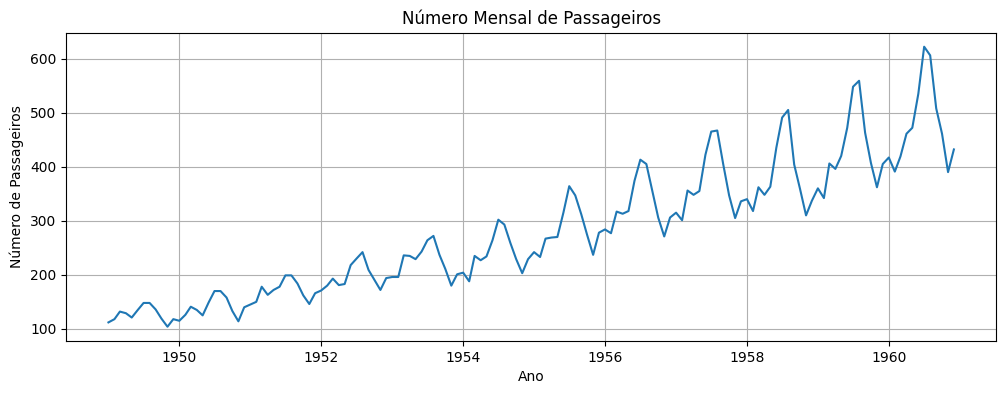

In [24]:
# Gráfico da Série Temporal AirPassagers
plt.figure(figsize=(12, 4))
plt.plot(air_series)
plt.title('Número Mensal de Passageiros')
plt.xlabel('Ano')
plt.ylabel('Número de Passageiros')
plt.grid(True)
plt.show()

#### Estacionaridade nos Modelos ARIMA

Nos modelos __ARIMA__ é necessário que a série temporal seja estacionária, ou seja, que tenha propriedades estatísticas (média, variância) constantes ao longo do tempo. Isto é crucial porque os componentes __AR__ e __MA__ do modelo assumem que as relações temporais que eles capturam são estáveis. Se a série tiver tendências ou variabilidade inconstante (não estacionária), essas relações mudam, tornando o modelo __ARMA__ ineficaz e as previsões não confiáveis. O componente __'I'__ (Integrado) do __ARIMA__ existe precisamente para resolver isto, representando a diferenciação necessária para transformar a série em estacionária antes de aplicar os componentes __AR__ e __MA__. Portanto, garantir a estacionaridade é fundamental para que o modelo __ARIMA__ funcione corretamente.

##### Teste ADF (Augmented Dickey-Fuller test)

É um dos testes estatísticos mais comuns utilizados para verificar se uma série temporal é estacionária ou não. Especificamente, ele testa a presença de uma raiz unitária (unit root) na série.  

Pontos chave sobre o Teste ADF:  
* __Objetivo Principal:__ Determinar se uma série temporal precisa ser diferenciada para se tornar estacionária;
* __Raiz Unitária:__ É uma característica de processos estocásticos (como séries temporais) que podem fazer com que choques (eventos inesperados) tenham um efeito persistente sobre a série, impedindo-a de retornar à sua média de longo prazo. A presença de uma raiz unitária é uma causa comum de não estacionaridade.

##### Conceito de Diferenciação

__Diferenciação__ em séries temporais é uma transformação usada para tornar uma série __não estacionária__ (com tendência, por exemplo) em __estacionária__.

Basicamente, calcula-se a __diferença entre observações consecutivas__:  
$$\Delta Y_t = Y_t - Y_{t-1}$$

$\Delta Y_t$ -  representa o valor da série diferenciada no tempo t.  
$Y_t$ - é o valor da série original no tempo t.  
$Y_{t-1}$ - é o valor da série original no tempo t-1 (o período anterior).

Isto cria uma nova série que representa as mudanças ou variações de um período para o outro, ajudando a remover a tendência e a estabilizar a média da série.

In [25]:
# Verificar a estacionaridade com o teste ADF
result_adf = adfuller(air_series)

# Resultados do Teste ADF
statistic_test = result_adf[0]  # Estatística de Teste ADF
p_value = result_adf[1]  # Valor-p
lags_used = result_adf[2]  # Número de Lags (Defasagens) Utilizados (Number of Lags Used)
observations_used = result_adf[3]  # Número de Observações Utilizadas (Number of Observations Used)

print('\nResultados do Teste ADF (Augmented Dickey-Fuller):')
print(f'Estatística de Teste ADF: {statistic_test}')
print(f'Valor-p: {p_value}')
print(f'Número de Lags: {lags_used}')
print(f'Número de Observações: {observations_used}')
print('Valores Críticos:')
for key, value in result_adf[4].items(): # type: ignore
    print(f'\t{key}: {value}')

# Interpretação do p-value:
# Se p-value > 0.05: Não rejeitamos a hipótese nula (H0), a série não é estacionária.
# Se p-value <= 0.05: Rejeitamos H0, a série é estacionária.
if p_value > 0.05:
    print("\nConclusão: A série NÃO é estacionária (p-value > 0.05).")
else:
    print("\nConclusão: A série É estacionária (p-value <= 0.05).")


Resultados do Teste ADF (Augmented Dickey-Fuller):
Estatística de Teste ADF: 0.8153688792060482
Valor-p: 0.991880243437641
Número de Lags: 13
Número de Observações: 130
Valores Críticos:
	1%: -3.4816817173418295
	5%: -2.8840418343195267
	10%: -2.578770059171598

Conclusão: A série NÃO é estacionária (p-value > 0.05).


##### Observações

Como podemos verificar com o resultado do Teste ADF a série não é estacionária.
Isto confirma o que vimos no gráfico, presença de tendência e sazonalidade. Como foi dito anteriormente uma série não estacionária precisa de diferenciação, o componente 'I' no modelo ARIMA mas como a série apresenta sazonalidade vamos utilizar o modelo SARIMA (extensão do modelo ARIMA).

In [26]:
# Tornar a série temporal estacionária com o método diff()
def estacionar_serie(series, p_value_limit=0.05, max_diff=5):
    # Iniciar p-value com um valor para iniciar o loop 
    p_value = 1
    diff_count = 0
    test_series = series.copy() # Criar uma cópia para não alterar a original

    # Loop para aplicar diff() até a série ficar estacionária
    while p_value > p_value_limit:
        # Calculo da diferenciação
        series_diff = test_series.diff()

        # Eliminar valores nulos (NaNs)
        series_diff_clean = series_diff.dropna()

        # Teste ADF
        result_adf = adfuller(series_diff_clean)
        p_value = result_adf[1]
        diff_count += 1

        if p_value > p_value_limit:
            print(f'\nIteração {diff_count}: A série NÃO é estacionária.\np-value = {p_value:.6f}.')
            test_series = series_diff_clean # Atualizar a série a ser testada na próxima iteração
        else:
            print(f'\nIteração {diff_count}: A série É estacionária.\np-value = {p_value:.6f}.')

        if p_value > 0.05 and diff_count > 5: # Para evitar loops infinitos
            print("\nAlcançado o número máximo de diferenciações sem estacionariedade.")

    return test_series, result_adf # type: ignore

serie_estacionaria, ADF = estacionar_serie(air_series)

serie_estacionaria.head()



Iteração 1: A série NÃO é estacionária.
p-value = 0.054213.

Iteração 2: A série É estacionária.
p-value = 0.000000.


Date
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
1949-06-01    14.0
Name: Passengers, dtype: float64

Como vimos nas células anteriores, aplicámos um método manual de diferenciação com `diff()` para tornar a série temporal estacionária. Esta é uma etapa importante para garantir que os modelos de previsão baseados em ARIMA possam funcionar corretamente.

No entanto, além de garantir estacionariedade, é necessário identificar um conjunto adequado de parâmetros que permitam ao modelo capturar a dinâmica da série de forma robusta e precisa.

É precisamente isso que abordaremos a seguir: a definição do modelo **SARIMAX**, os seus parâmetros e, posteriormente, a seleção automática desses parâmetros através da função `auto_arima`, de forma a obtermos previsões com o melhor desempenho possível.

#### Modelo SARIMAX

O modelo __SARIMAX__ (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors) é uma extensão do modelo ARIMA que permite lidar com:
* Componentes sazonais;
* Variáveis externas (exógenas) — embora estas não sejam usadas no nosso caso.

Este modelo é amplamente utilizado para séries temporais que apresentam tendência e sazonalidade.

##### Parâmetros do SARIMAX

Um modelo SARIMAX é definido por dois grupos de parâmetros:

Parâmetros do modelo ARIMA (não sazonal):
* __p:__ número de termos autoregressivos (AR);
* __d:__ número de diferenciações para tornar a série estacionária;
* __q:__ número de termos da média móvel (MA)

Parâmetros do modelo sazonal:
* __P:__ número de termos AR sazonais;
* __D:__ número de diferenciações sazonais;
* __Q:__ número de termos MA sazonais;
* __s:__ período da sazonalidade (ex: s=12 para dados mensais com ciclo anual)

##### Escolher os melhores parâmetros manualmente

Na escolha manual dos parâmetros, normalmente seguem-se os seguintes passos:
* Verificar estacionariedade e aplicar diferenciação (d, D) se necessário;
* Usar gráficos ACF e PACF para estimar:
    - __p__ e __q__ (PACF e ACF da série diferenciada);
    - __P__ e __Q__ (PACF e ACF da série diferenciada sazonalmente).
* Ajustar diferentes modelos e comparar métricas como AIC, BIC e resíduos;

Esse processo pode ser demorado e subjetivo, especialmente quando há sazonalidade.

##### Abordagem automática com __auto_arima__

Para facilitar este processo, vamos utilizar a função auto_arima da biblioteca pmdarima, que:
* Testa automaticamente múltiplas combinações de (p,d,q) e (P,D,Q,s);
* Escolhe o melhor modelo com base em métricas estatísticas (ex: AIC/BIC);
    * __AIC__ (Akaike Information Criterion), __BIC__ (Bayesian Information Criterion)
* Permite identificar rapidamente os parâmetros ideais para o modelo SARIMAX.

Assim, conseguimos acelerar o processo de modelagem, mantendo a robustez e a qualidade estatística.

In [27]:
# Divisão da série em treino e teste

# train = 80% do tamanho da série original
# teste = 20% do tamanho da série original

# shuffle=False => Como estamos a trabalhar com uma série temporal não é necessário embaralhar (shuffle) o dataset

train, test = train_test_split(air_series, test_size=0.2, shuffle=False)

In [28]:
# Encontrar os melhores parâmetros SARIMA com auto_arima

modelo_auto = auto_arima(train,  # Dataset - time series
                         seasonal=True,  # Como vimos a serie é sazonal
                         m=12,  # Sazonalidade mensal
                         stationary=False,  # A serie não é estacionária
                         trace=True) # Info sobre os modelos testados

# Ver os melhores parâmetros encontrados
print("Melhor ordem (p,d,q):", modelo_auto.order)
print("Melhor ordem sazonal (P,D,Q,s):", modelo_auto.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=757.714, Time=0.50 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=757.826, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=755.750, Time=0.06 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=756.380, Time=0.09 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=755.499, Time=0.02 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=755.982, Time=0.09 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=757.649, Time=0.13 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=756.771, Time=0.04 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=756.022, Time=0.04 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=756.011, Time=0.03 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=757.976, Time=0.06 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AIC=757.438, Time=0.05 sec

Best model:  ARIMA(1,1,0)(0,1,0)[12]          
Total fit time: 1.131 seconds
Melhor ordem (p,d,q): (1, 1, 0)
Melhor ordem sazonal (P,D,Q,s): (0, 1, 0, 12)


In [29]:
# Construção do modelo SARIMAX com os parâmetros encontrados
sarima_model = SARIMAX(train,
                       order=modelo_auto.order,
                       seasonal_order=modelo_auto.seasonal_order,
                       enforce_stationarity=False,
                       enforce_invertibility=False)

'''enforce_stationarity=False -> O SARIMAX vai aplicar as diferenciações automaticamente com base
nos parâmetros (d, D) encontrados no auto_arima.
enforce_invertibility=False -> O auto_arima já considerou se a solução é invertível ao escolher o melhor modelo.
Forçar invertibility=True pode excluir soluções válidas ou aumentar o AIC/BIC.
'''

sarima_fit = sarima_model.fit()
print(sarima_fit.summary()) # type: ignore

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  115
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                -372.414
Date:                            Sun, 17 Aug 2025   AIC                            748.828
Time:                                    00:17:54   BIC                            754.058
Sample:                                01-01-1949   HQIC                           750.946
                                     - 07-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2063      0.091     -2.271      0.023      -0.384      -0.028
sigma2        93.3784     13.542   

In [30]:
# Previsões
n_test = len(test)
forecast = sarima_fit.forecast(steps=n_test) # type: ignore


In [31]:
# Avaliação do modelo
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

MAE: 28.57
RMSE: 35.10
R2: 0.80


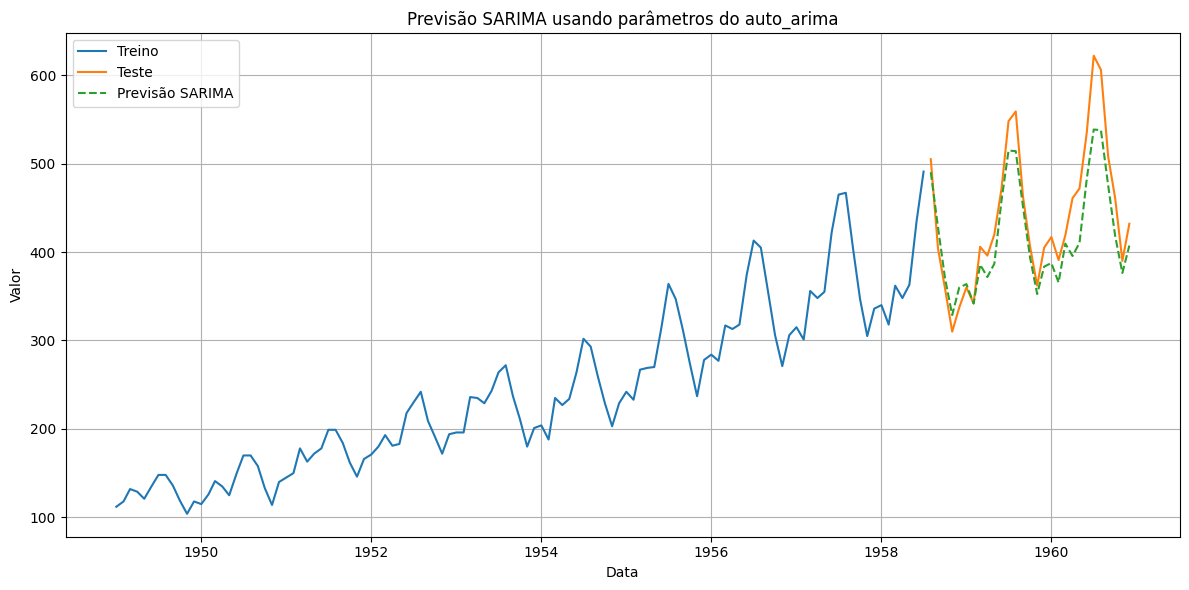

In [32]:
# Gráfico com treino, teste e previsão
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Treino')
plt.plot(test.index, test, label="Teste")
plt.plot(test.index, forecast, label='Previsão SARIMA', linestyle='--')
plt.title('Previsão SARIMA usando parâmetros do auto_arima')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
train.tail()

Date
1958-03-01    362
1958-04-01    348
1958-05-01    363
1958-06-01    435
1958-07-01    491
Name: Passengers, dtype: int64

In [34]:
test.head()

Date
1958-08-01    505
1958-09-01    404
1958-10-01    359
1958-11-01    310
1958-12-01    337
Name: Passengers, dtype: int64

##### Observações:
- O modelo capturou bem o padrão sazonal e a tendência de crescimento da série.
- Em algumas zonas, há uma algumas variações, mas o comportamento global da série foi bem seguido.

O modelo selecionado foi:  
SARIMAX(1, 1, 0) × (0, 1, 0, 12)

Significado:
- `order=(1,1,0)`:
  - 1 termo autoregressivo (AR)
  - 1 diferenciação não sazonal (d)
  - 0 termos de média móvel (MA)
- `seasonal_order=(0,1,0,12)`:
  - 1 diferenciação sazonal (D), com periodicidade 12 (mensal)
  - Sem termos sazonais AR ou MA


##### Sumário do Modelo (`sarima_fit.summary()`)

- **Coeficiente AR.L1:** -0.2063 => significativo (p = 0.023)
- **Sigma² (variância dos resíduos):** 93.38
- **Teste Ljung-Box:** p = 0.87 => sem autocorrelação nos resíduos
- **Jarque-Bera:** p = 0.27 => resíduos aproximadamente normais
- **Teste de Heterocedasticidade:** p = 0.94 => resíduos homocedásticos

Os resíduos do modelo comportam-se como ruído branco, o que é desejável.


##### Métricas de Avaliação

- **MAE** (Erro Absoluto Médio):
  - mostra, em média, quantas unidades a previsão está afastada do valor real (28.57)
- **RMSE** (Raiz do Erro Quadrático Médio):
  - Penaliza os erros maiores (por causa da elevação ao quadrado).
  - Útil quando é importante minimizar grandes desvios entre previsão e valor real. (35.10)

A diferença entre os dois valores indica que:
  - O modelo teve **alguns erros pontuais mais elevados** — ou seja, acertou bem na maior parte do tempo, mas falhou com mais força em certos pontos.

Se MAE e RMSE fossem muito próximos, isso indicaria uma **distribuição mais uniforme dos erros**.

##### Conclusão Geral

O modelo SARIMAX ajustado com os parâmetros do `auto_arima`:

- Modela bem a **tendência** e a **sazonalidade**
- Tem **erros de previsão razoáveis**
- Serve como uma **baseline** para comparações futuras com modelos mais sofisticados.